Load Dataset

In [6]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

housing = fetch_california_housing(as_frame=True)
df = housing.frame

print(df.head())
print(df.info())
print(df.describe())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population

Understand the data

In [7]:
print(df.isnull().sum())
print(df.columns)
print(df['MedHouseVal'].describe())
print(df.corr(numeric_only=True)['MedHouseVal'].sort_values(ascending=False))

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')
count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: MedHouseVal, dtype: float64
MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


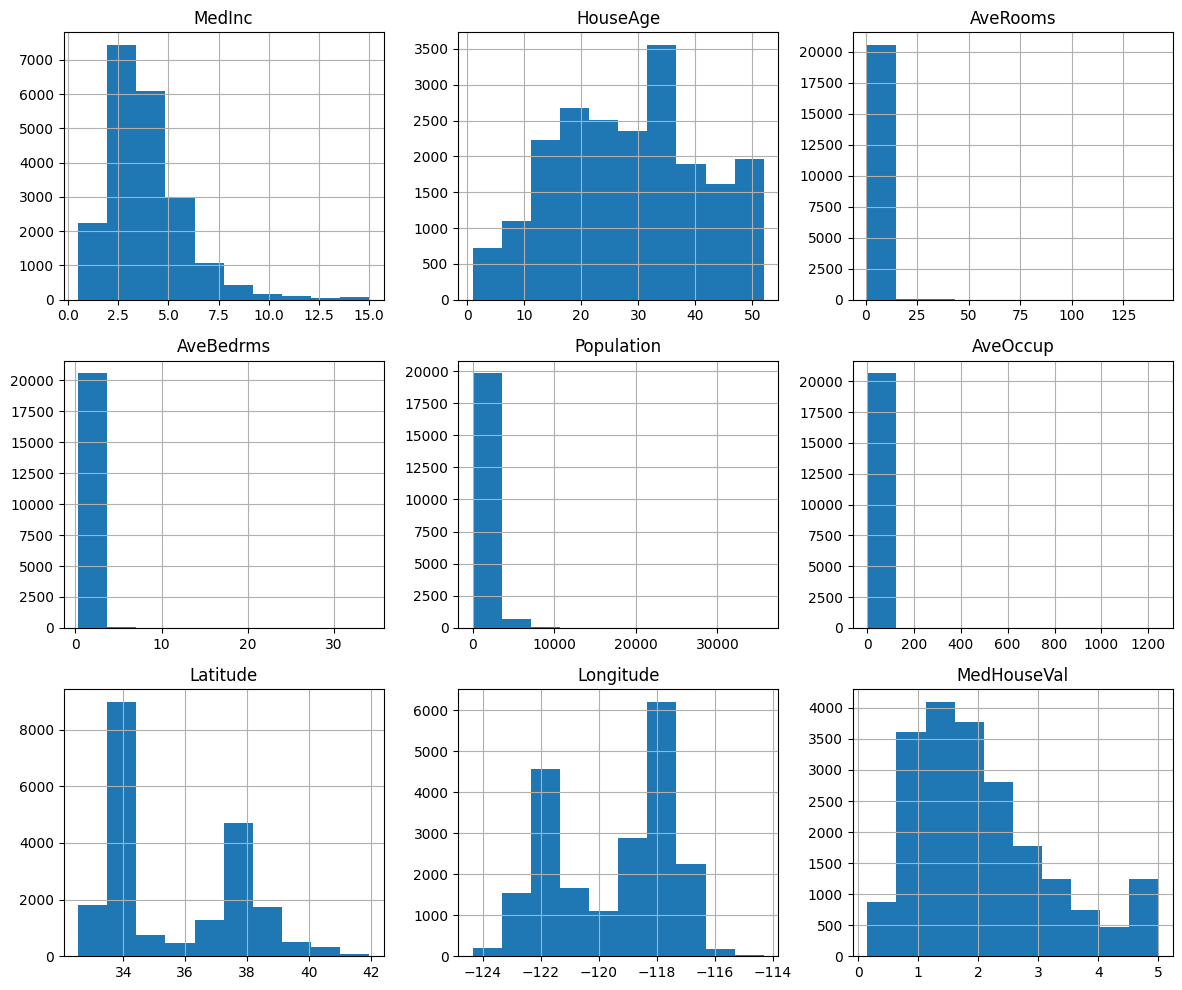

In [8]:
import matplotlib.pyplot as plt

df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

Separate features and target

In [9]:
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

Split into train, validation, and test sets

In [10]:
from sklearn.model_selection import train_test_split

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=42
)

Choose preprocessing methods to compare
    
    In this section, the input features and target variable are separated. Since MedHouseVal is continuous, the supervised task is regression.

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Model Training

    Two regression models are tested: Random Forest Regressor and Gradient Boosting Regressor. These models are chosen because they are strong methods for nonlinear tabular data.

Train Model 1: Random Forest Regressor

In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

rf_val_pred = rf.predict(X_val)

rf_mae = mean_absolute_error(y_val, rf_val_pred)
rf_rmse = np.sqrt(mean_squared_error(y_val, rf_val_pred))
rf_r2 = r2_score(y_val, rf_val_pred)

print("Random Forest Validation MAE:", rf_mae)
print("Random Forest Validation RMSE:", rf_rmse)
print("Random Forest Validation R^2:", rf_r2)

Random Forest Validation MAE: 0.3455827316076296
Random Forest Validation RMSE: 0.5268853821261901
Random Forest Validation R^2: 0.7988328653594216


Train Model 2: Gradient Boosting Regressor

In [13]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)

gbr_val_pred = gbr.predict(X_val)

gbr_mae = mean_absolute_error(y_val, gbr_val_pred)
gbr_rmse = np.sqrt(mean_squared_error(y_val, gbr_val_pred))
gbr_r2 = r2_score(y_val, gbr_val_pred)

print("Gradient Boosting Validation MAE:", gbr_mae)
print("Gradient Boosting Validation RMSE:", gbr_rmse)
print("Gradient Boosting Validation R^2:", gbr_r2)

Gradient Boosting Validation MAE: 0.3801723666388776
Gradient Boosting Validation RMSE: 0.5440847330294147
Gradient Boosting Validation R^2: 0.7854849286121708


Compare preprocessing methods

In [14]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)

gbr_val_pred = gbr.predict(X_val)

gbr_mae = mean_absolute_error(y_val, gbr_val_pred)
gbr_rmse = np.sqrt(mean_squared_error(y_val, gbr_val_pred))
gbr_r2 = r2_score(y_val, gbr_val_pred)

print("Gradient Boosting Validation MAE:", gbr_mae)
print("Gradient Boosting Validation RMSE:", gbr_rmse)
print("Gradient Boosting Validation R^2:", gbr_r2)

Gradient Boosting Validation MAE: 0.3801723666388776
Gradient Boosting Validation RMSE: 0.5440847330294147
Gradient Boosting Validation R^2: 0.7854849286121708


In [15]:
gbr_scaled = GradientBoostingRegressor(random_state=42)
gbr_scaled.fit(X_train_scaled, y_train)
gbr_scaled_pred = gbr_scaled.predict(X_val_scaled)

print("GBR scaled RMSE:", np.sqrt(mean_squared_error(y_val, gbr_scaled_pred)))
print("GBR scaled R^2:", r2_score(y_val, gbr_scaled_pred))

GBR scaled RMSE: 0.5440847330294147
GBR scaled R^2: 0.7854849286121708


Random Forest Tuning

In [16]:
from sklearn.model_selection import GridSearchCV

rf_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=rf_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

print("Best RF params:", rf_search.best_params_)
print("Best RF CV score:", rf_search.best_score_)

Best RF params: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best RF CV score: 0.7955177994016037


Gradient Boosting Tuning

In [17]:
from sklearn.ensemble import GradientBoostingRegressor

gbr_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [2, 3, 4],
    'subsample': [0.8, 1.0]
}

gbr_search = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid=gbr_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

gbr_search.fit(X_train, y_train)

print("Best GBR params:", gbr_search.best_params_)
print("Best GBR CV score:", gbr_search.best_score_)

print("Best GBR params:", gbr_search.best_params_)
print("Best GBR CV score:", gbr_search.best_score_)

Best GBR params: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
Best GBR CV score: 0.8198138209225322
Best GBR params: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
Best GBR CV score: 0.8198138209225322


Pick the best version of each model

    Model performance is evaluated using MAE, RMSE, and R², since these are standard regression metrics. Regression accuracy is not used because accuracy is a classification metric.

In [18]:
best_rf = rf_search.best_estimator_
best_gbr = gbr_search.best_estimator_

best_rf_val_pred = best_rf.predict(X_val)
best_gbr_val_pred = best_gbr.predict(X_val)

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Random Forest tuned
rf_mae = mean_absolute_error(y_val, best_rf_val_pred)
rf_rmse = np.sqrt(mean_squared_error(y_val, best_rf_val_pred))
rf_r2 = r2_score(y_val, best_rf_val_pred)

# Gradient Boosting tuned
gbr_mae = mean_absolute_error(y_val, best_gbr_val_pred)
gbr_rmse = np.sqrt(mean_squared_error(y_val, best_gbr_val_pred))
gbr_r2 = r2_score(y_val, best_gbr_val_pred)

In [29]:
print("Random Forest:")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)

print("\nGradient Boosting:")
print("MAE:", gbr_mae)
print("RMSE:", gbr_rmse)
print("R2:", gbr_r2)

Random Forest:
MAE: 0.34305976921355813
RMSE: 0.5251733242748037
R2: 0.8001380836196232

Gradient Boosting:
MAE: 0.3422472886967428
RMSE: 0.5011662620573375
R2: 0.8179928769976206


In [30]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boosting'],
    'MAE': [rf_mae, gbr_mae],
    'RMSE': [rf_rmse, gbr_rmse],
    'R2': [rf_r2, gbr_r2]
})

print(results)

               Model       MAE      RMSE        R2
0      Random Forest  0.343060  0.525173  0.800138
1  Gradient Boosting  0.342247  0.501166  0.817993


LOWER RMSE, LOWER MAE, HIGHER R² → better
Gradient Boosting is best.

Evaluate Final Model on test set

In [31]:
final_model = best_gbr  
final_test_pred = final_model.predict(X_test)

final_mae = mean_absolute_error(y_test, final_test_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, final_test_pred))
final_r2 = r2_score(y_test, final_test_pred)

print("Final Test MAE:", final_mae)
print("Final Test RMSE:", final_rmse)
print("Final Test R^2:", final_r2)

Final Test MAE: 0.32871682807112923
Final Test RMSE: 0.4879556146463012
Final Test R^2: 0.8183004803702755


Predicted vs Actual

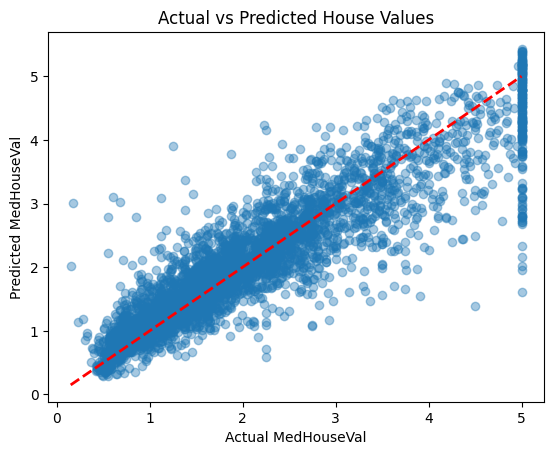

In [32]:
plt.scatter(y_test, final_test_pred, alpha=0.4)
plt.xlabel("Actual MedHouseVal")
plt.ylabel("Predicted MedHouseVal")
plt.title("Actual vs Predicted House Values")
#add 45 degree line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.show()

Residual Plot

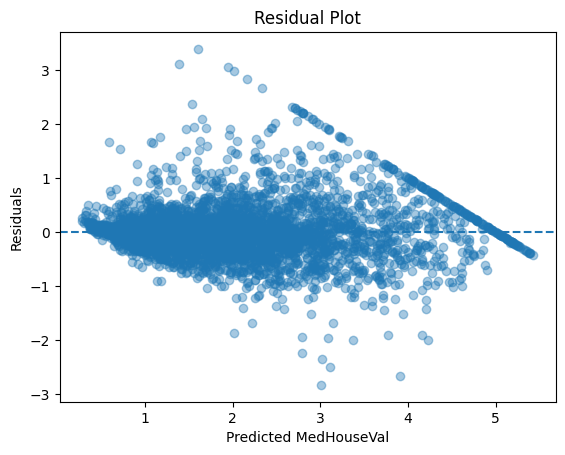

In [33]:
residuals = y_test - final_test_pred

plt.scatter(final_test_pred, residuals, alpha=0.4)
plt.axhline(0, linestyle='--')
plt.xlabel("Predicted MedHouseVal")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

Feature Importance

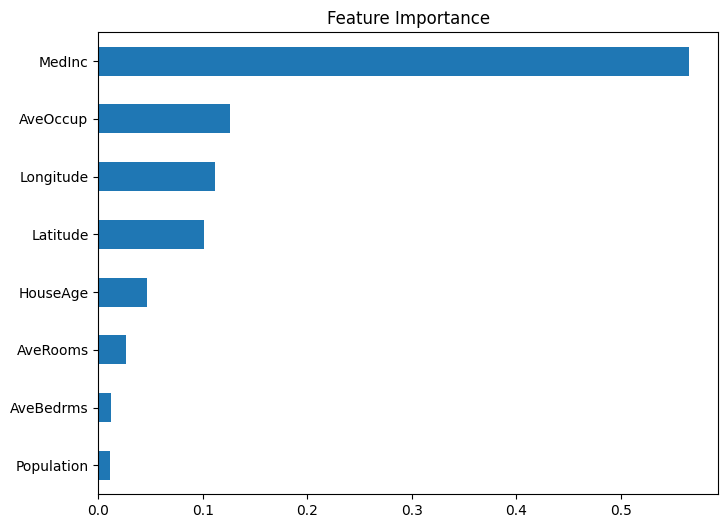

In [34]:
import pandas as pd

feature_importance = pd.Series(final_model.feature_importances_, index=X.columns)
feature_importance.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance")
plt.show()